# Predict Total Sales using Facebook Prophet - Exercise

![Namespace Labs](../../../../labs.png)

### Installation

pip install fbprophet

## Predict total sales

In [1]:
from prophet import Prophet
import pandas as pd

In [2]:
df = pd.read_csv('sales.csv')

In [3]:
df.head()

,ds,y
0,1/10/2011,36529.3764
1,1/11/2011,102403.8663
2,1/12/2011,36177.7578
3,1/13/2011,31005.6454
4,1/14/2011,71539.6626


In [4]:
# Print the head of the dataset


In [5]:
df.tail()

,ds,y
300,9/5/2011,55634.5004
301,9/6/2011,42359.4562
302,9/7/2011,51529.7315
303,9/8/2011,40329.0800
304,9/9/2011,44269.7119


In [6]:
# Print the tail of the dataframe


In [7]:
model = Prophet()
model.fit(df)

16:31:18 - cmdstanpy - INFO - Chain [1] start processing
16:31:19 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
# Create an instance of prophet
# Fit the data to the model


In [9]:
future = model.make_future_dataframe(periods=365)
future.tail()

,ds
665,2012-12-04
666,2012-12-05
667,2012-12-06
668,2012-12-07
669,2012-12-08


In [10]:
# Create a dataframe for future dates
# Print the head of the dataframe


In [11]:
# Make predictions on the model
predictions = model.predict(future)

In [12]:
predictions.head(1)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-12-01,47328.720076,21326.309064,69613.693398,47328.720076,47328.720076,-1886.557492,-1886.557492,-1886.557492,-1886.557492,-1886.557492,-1886.557492,0.0,0.0,0.0,45442.162585


In [13]:
# Display one row from the predictions


In [14]:
predictions[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
665,2012-12-04,203530.541695,166543.590359,240236.609071
666,2012-12-05,196116.656529,159910.647970,233857.903793
667,2012-12-06,207099.534442,171899.307701,244674.750926
668,2012-12-07,193114.394915,157678.395497,229107.255051
669,2012-12-08,219504.672209,182442.004309,255828.977592


In [15]:
# Display the tail of the forecasts


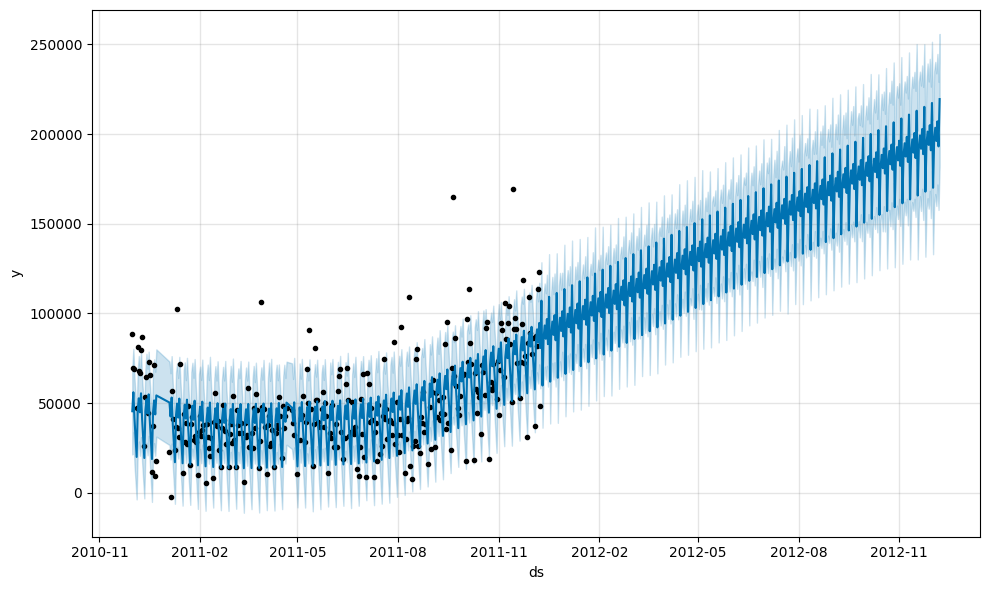

In [16]:
fig1 = model.plot(predictions)

In [17]:
# Plot the forecast

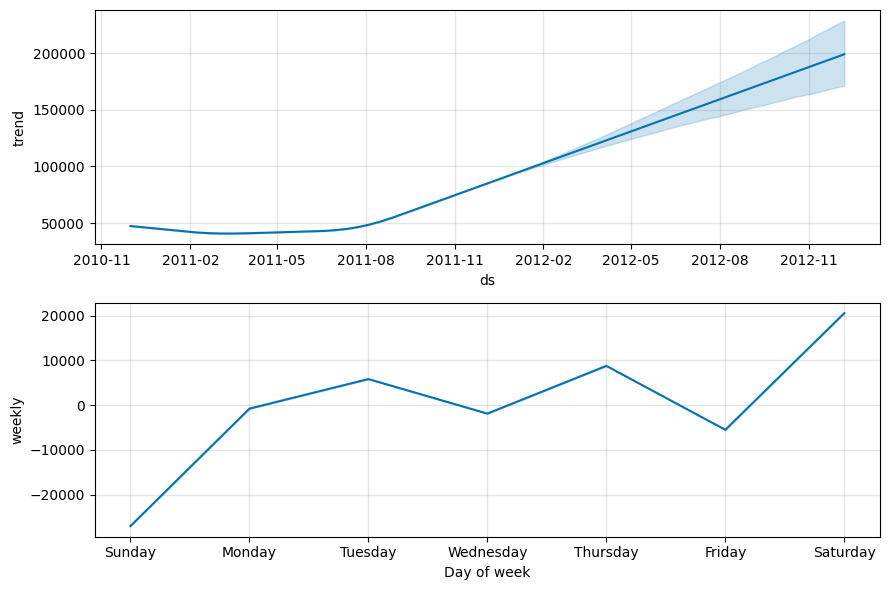

In [18]:
fig2 = model.plot_components(predictions)

In [19]:
# Plot the model components


In [ ]:
df

In [32]:
from prophet.diagnostics import cross_validation
df_cv = cross_validation(model, horizon = '50 days')
df_cv

  0%|          | 0/7 [00:00<?, ?it/s]

16:55:57 - cmdstanpy - INFO - Chain [1] start processing
16:55:57 - cmdstanpy - INFO - Chain [1] done processing
16:55:57 - cmdstanpy - INFO - Chain [1] start processing
16:55:58 - cmdstanpy - INFO - Chain [1] done processing
16:55:58 - cmdstanpy - INFO - Chain [1] start processing
16:55:59 - cmdstanpy - INFO - Chain [1] done processing
16:56:00 - cmdstanpy - INFO - Chain [1] start processing
16:56:00 - cmdstanpy - INFO - Chain [1] done processing
16:56:01 - cmdstanpy - INFO - Chain [1] start processing
16:56:01 - cmdstanpy - INFO - Chain [1] done processing
16:56:02 - cmdstanpy - INFO - Chain [1] start processing
16:56:02 - cmdstanpy - INFO - Chain [1] done processing
16:56:03 - cmdstanpy - INFO - Chain [1] start processing
16:56:04 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2011-05-24,53143.043626,34240.590803,71180.492465,55913.6541,2011-05-23
1,2011-05-25,39282.173744,20881.101633,58873.902358,36469.9428,2011-05-23
2,2011-05-26,47973.600564,29752.443301,68159.779142,50144.9709,2011-05-23
3,2011-05-27,45628.605544,26088.386989,64422.171282,42630.6069,2011-05-23
4,2011-05-29,19734.366975,820.032460,39825.019363,10884.5330,2011-05-23
...,...,...,...,...,...,...
292,2011-12-05,65255.438122,43111.786770,88604.688134,87204.4932,2011-10-20
293,2011-12-06,75182.867261,53169.901218,98837.231811,81884.8387,2011-10-20
294,2011-12-07,64936.057250,43228.011738,88037.257542,113365.0922,2011-10-20
295,2011-12-08,77551.825910,54020.543782,100200.287840,122940.8478,2011-10-20


In [12]:
# Perform cross validation


INFO:fbprophet:Making 7 forecasts with cutoffs between 2011-05-23 00:00:00 and 2011-10-20 00:00:00


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2011-05-24,53291.250755,34015.556411,71698.368004,55913.6541,2011-05-23
1,2011-05-25,39300.378504,21584.926129,59457.707014,36469.9428,2011-05-23
2,2011-05-26,48076.603078,30090.327092,66549.954236,50144.9709,2011-05-23
3,2011-05-27,45712.752782,27554.415191,64722.872238,42630.6069,2011-05-23
4,2011-05-29,19694.821822,1140.490427,40695.620992,10884.5330,2011-05-23


In [47]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,5 days,2.929238e+08,17115.017390,12232.852837,0.310822,0.276451,0.283737,0.804598
1,6 days,2.573700e+08,16042.754207,11517.322864,0.328829,0.276451,0.283667,0.833333
2,7 days,2.924931e+08,17102.429495,12517.175032,0.415523,0.276451,0.317609,0.793103
3,8 days,3.576965e+08,18912.865449,13340.107502,0.440206,0.281053,0.331767,0.758621
4,9 days,3.646899e+08,19096.856053,14079.810293,0.493851,0.292694,0.365828,0.793103


In [13]:
# Display the performance metrics


,horizon,mse,rmse,mae,mape,mdape,coverage
0,5 days,2.940757e+08,17148.634117,12208.925404,0.308797,0.273485,0.839080
1,6 days,2.592895e+08,16102.468248,11565.669433,0.328909,0.273485,0.867816
2,7 days,2.959048e+08,17201.883092,12606.691907,0.416869,0.273485,0.827586
3,8 days,3.653123e+08,19113.144610,13488.731443,0.441266,0.292915,0.793103
4,9 days,3.711585e+08,19265.473981,14195.906760,0.493750,0.303192,0.793103


/home/janusz/Desktop/udemy data science/Machine Learning/venv/lib/python3.12/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/home/janusz/Desktop/udemy data science/Machine Learning/venv/lib/python3.12/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


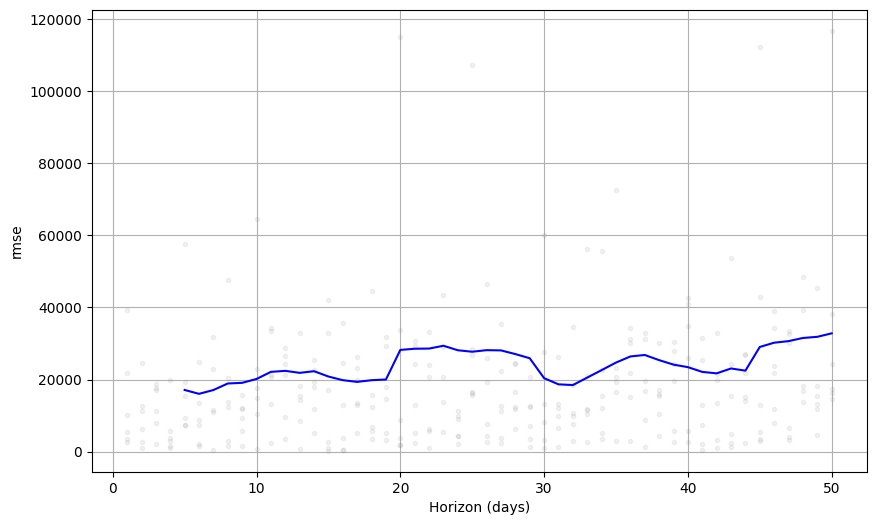

In [45]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='rmse')

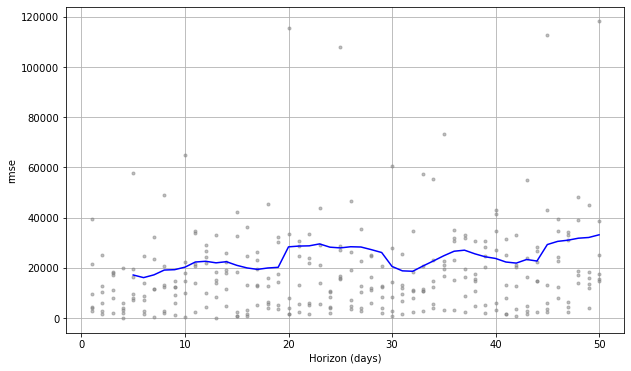

In [14]:
# Plot the performance metrics


Happy Coding!